# E2: trends

AIMIP evaluations of predicted variable trends in the train (1979-2014, in-sample) and test (2015-2024, out of sample) periods.

In [1]:
import xarray as xr
import numpy as np
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    ERA5_1DEG,
    EVALUATION_PRESSURE_LEVELS,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    compute_global_mean,
    compute_decadal_trend,
    compute_annual_mean,
    linear_fit,
    convert_tdas_to_huss,
    load_gfdl_am4_from_cmip6_gcs,
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
    CATEGORICAL_COLORS,
)

In [2]:
TRAINING_DATES = ('1979-01-01', '2014-12-31')
TEST_DATES = ('2015-01-01', '2024-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = os.environ.get('AIMIP_FIGURES_DIR', './figures')
CACHE_DIR = os.environ.get('AIMIP_CACHE_DIR', './cached')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
RESET_CACHE = False
RESTORE_CACHE = True

## How to run this notebook

This notebook runs in one of two modes, set by `RESET_CACHE` / `RESTORE_CACHE` in the cell above.

**Reproduce the manuscript figures from the bundled cache** — the default (`RESTORE_CACHE = True`, `RESET_CACHE = False`). No raw data is needed: run the setup cells above, then the **Restore minimal cache** cell, then the cells in the **Manuscript figures** section. You can skip the **Data loading & processing** section and the intermediate diagnostic cells — they read the full (~1.8 TB) raw dataset.

**Regenerate the cache from the raw dataset** (`RESET_CACHE = True`, `RESTORE_CACHE = False`). Download the full submissions (see the repo `README.md` → Data) and run every cell top to bottom; the minimal cache is rewritten from scratch.

## Data loading & processing

*Skip this section when using the bundled cache.* These cells read the full raw dataset and are only needed to regenerate the cache (`RESET_CACHE = True`).

In [3]:
monthly_data, _ = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

ACE2.1-ERA5
specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/h

In [4]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [5]:
# specific fixes

# add coordinates to DLESyM
monthly_data['DLESyM'] = add_latlon_to_dlesym(monthly_data['DLESyM'])

# ArchesWeather surface temperature has different units (C)
for experiment_submission in ['ArchesWeather', 'ArchesWeatherGen']:
    monthly_data[experiment_submission]['ts'] = monthly_data[experiment_submission].ts + 273.15

In [6]:
# open CMIP6 GFDL CM4 data
other_variables = ['lat', 'lat_bnds', 'lon', 'lon_bnds']
gfdl_cm4_monthly_1deg, missing_paths = load_gfdl_am4_from_cmip6_gcs(
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
    EVALUATION_VARIABLES,
    other_variables,
)
monthly_data['GFDL-CM4'] = gfdl_cm4_monthly_1deg.expand_dims({'realization': [1]})

gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/hus/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/huss/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/pr/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ps/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/psl/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ta/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/tas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ts/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ua/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/uas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/va/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/vas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/zg/gr1/v2

In [7]:
era5_monthly_1deg, _ = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    n_realizations=1,
)
era5_monthly_1deg = (
    era5_monthly_1deg['ERA5']
    .isel(realization=0).squeeze().drop_vars('realization')
    .drop_vars(['forecast_period', 'originating_centre'])
)

ERA5
specific_humidity
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_hus_1978-2024.nc
surface_specific_humidity
Not found: ../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc
dew_point_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tdas_1978-2024.nc
precipitation_flux
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc
surface_air_pressure
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ps_1978-2024.nc
air_pressure_at_sea_level
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_psl_1978-2024.nc
air_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc
air_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tas_1978-2024.nc
surface_temperature
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ts_1978-2024.nc
eastward_wind
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ua_1978-2024.nc
eastward_wind


/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_uas_1978-2024.nc
northward_wind
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_va_1978-2024.nc
northward_wind
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_vas_1978-2024.nc
geopotential_height
../../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_zg_1978-2024.nc


/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/notebooks/aimip_data_utils.py:655: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

In [8]:
era5_monthly_1deg = convert_tdas_to_huss(era5_monthly_1deg)

Converting 'tdas' to 'huss'.


In [9]:
# For GFDL-CM4, propagate any-NaN cells to NaN across the full time axis
# for pressure-level variables. CM4's surface pressure varies in time →
# cells near topography are intermittently below-surface. Computing means
# or trends from a partial time series introduces small errors and makes the
# comparison domain inconsistent with ERA5. The existing downstream
# isnull().all() mask correctly handles these cells once their means are NaN.
for _var in list(monthly_data['GFDL-CM4'].data_vars):
    _da = monthly_data['GFDL-CM4'][_var]
    if 'plev' in _da.dims:
        _below_surface_any = _da.isnull().any('time')
        monthly_data['GFDL-CM4'][_var] = _da.where(~_below_surface_any)

In [10]:
annual_mean_data = {}
for experiment_submission_name, dataset in monthly_data.items():
    print(experiment_submission_name)
    annual_mean = compute_annual_mean(dataset)
    annual_mean_data[experiment_submission_name] = annual_mean
annual_mean_era5 = compute_annual_mean(era5_monthly_1deg)

ACE2.1-ERA5
ArchesWeather
ArchesWeatherGen
cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM
NeuralGCM-HRD
GFDL-CM4


In [11]:
with ProgressBar():
    annual_mean_data = {
        k: v.compute() for k, v in annual_mean_data.items()
    }
    annual_mean_era5 = annual_mean_era5.compute()

[########################################] | 100% Completed | 147.46 s
[########################################] | 100% Completed | 181.24 s
[########################################] | 100% Completed | 180.51 s
[########################################] | 100% Completed | 314.16 s
[########################################] | 100% Completed | 9.68 ss
[########################################] | 100% Completed | 335.01 s
[########################################] | 100% Completed | 97.29 s
[########################################] | 100% Completed | 132.68 s
[########################################] | 100% Completed | 20.31 s
[########################################] | 100% Completed | 99.18 ss


In [12]:
regridded_annual_means_1deg = []
experiment_submissions_1deg = list(annual_mean_data.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg NeuralGCM at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    target_grid = annual_mean_era5.isel(year=0)[['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    regridded_annual_mean_1deg = regrid_dataset(
        annual_mean_data[experiment_submission_name],
        target_grid,
        sample_dims=['realization', 'year'],
        **regridder_kwargs
    )
    regridded_annual_means_1deg.append(
        regridded_annual_mean_1deg.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_annual_means_1deg = xr.concat(regridded_annual_means_1deg, dim='experiment_submission', join='outer', combine_attrs='override')
# Propagate model variable attrs to ERA5 so all downstream computations (trend, regrid) inherit them.
annual_mean_era5 = transfer_attrs(regridded_annual_means_1deg, annual_mean_era5)
# Mask ERA5 pressure-level data to AM4's valid (above-surface) domain.
# AM4 leaves below-surface grid cells as NaN; ERA5 artificially infills them.
# Masking ERA5 here ensures all downstream computations (regridding, trends, global
# means) are over the same physical domain as AM4, making metrics comparable.
_am4_1deg = regridded_annual_means_1deg.sel(experiment_submission='GFDL-CM4', drop=True)
for _var in annual_mean_era5.data_vars:
    if _var in _am4_1deg.data_vars and 'plev' in annual_mean_era5[_var].dims:
        _non_spatial = [d for d in _am4_1deg[_var].dims if d not in ('lat', 'lon', 'plev')]
        _below_surface = _am4_1deg[_var].isnull().all(_non_spatial)
        annual_mean_era5[_var] = annual_mean_era5[_var].where(~_below_surface)

ACE2.1-ERA5
ArchesWeather


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/br

GFDL-CM4


In [13]:
regridded_annual_means_2p8deg = []
experiment_submissions_2p8deg = list(annual_mean_data.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1 deg NeuralGCM-HRD at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    target_grid = (
        annual_mean_data['NeuralGCM']
        .isel(year=0, realization=0)
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_annual_mean_2p8_deg = regrid_dataset(
        annual_mean_data[experiment_submission_name],
        target_grid,
        sample_dims=['realization', 'year'],
        **regridder_kwargs
    )
    regridded_annual_means_2p8deg.append(
        regridded_annual_mean_2p8_deg.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_annual_means_2p8deg = xr.concat(regridded_annual_means_2p8deg, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5
ArchesWeather


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/br

GFDL-CM4


In [14]:
# regrid ERA5 to 2.8 deg NeuralGCM grid
destination_grid_era5 = (
    annual_mean_data['NeuralGCM']
    .isel(realization=0, year=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
regridded_annual_mean_era5_2p8deg = regrid_dataset(
    annual_mean_era5,
    destination_grid_era5,
    sample_dims=['year'],
    method='conservative',
)

In [15]:
regridded_annual_means_1deg = regridded_annual_means_1deg.sel(year=slice(1979, 2024)) # full years only
annual_mean_era5 = annual_mean_era5.sel(year=slice(1979, 2024))

regridded_annual_means_2p8deg = regridded_annual_means_2p8deg.sel(year=slice(1979, 2024)) # full years only
regridded_annual_mean_era5_2p8deg = regridded_annual_mean_era5_2p8deg.sel(year=slice(1979, 2024))

In [16]:
# ── Gridded trend maps: compute trends on native grids, then regrid ──────
# Computing trends before regridding minimises interpolation noise.
MAP_VARS = ['tas', 'pr']

def _native_trend_both_periods(ds, name):
    """Compute training+test decadal trends on a model's native grid."""
    available = [v for v in MAP_VARS if v in ds.data_vars]
    ds = ds[available]
    tr_train = compute_decadal_trend(ds, start=TRAINING_DATES[0], end=TRAINING_DATES[1], time_dim_name='year')
    # Some models (e.g. GFDL-CM4) only cover the training period; return NaN for test
    ds_test = ds.sel(year=slice(TEST_DATES[0], TEST_DATES[1]))
    if ds_test.sizes['year'] >= 2:
        tr_test = compute_decadal_trend(ds, start=TEST_DATES[0], end=TEST_DATES[1], time_dim_name='year')
    else:
        tr_test = tr_train * np.nan
    result = xr.concat(
        [tr_train.expand_dims({'time_period': ['training']}),
         tr_test.expand_dims({'time_period': ['test']})],
        dim='time_period',
    )
    # apply_ufunc may drop non-indexed coordinates (e.g. lat/lon on HEALPix grids);
    # reattach any spatial coords from the source that are still dimensionally compatible.
    spatial_coords = {
        k: v for k, v in ds.coords.items()
        if k not in ('year',) and all(d in result.dims for d in v.dims)
    }
    return result.assign_coords(spatial_coords)

trend_data_native = {}
for name, ds in annual_mean_data.items():
    print(name)
    trend_data_native[name] = _native_trend_both_periods(ds, name)

# ERA5 trends — already on 1° grid
tr_era5_train = compute_decadal_trend(
    annual_mean_era5[MAP_VARS], start=TRAINING_DATES[0], end=TRAINING_DATES[1], time_dim_name='year'
)
tr_era5_test = compute_decadal_trend(
    annual_mean_era5[MAP_VARS], start=TEST_DATES[0], end=TEST_DATES[1], time_dim_name='year'
)
trend_era5_native = xr.concat(
    [tr_era5_train.expand_dims({'time_period': ['training']}),
     tr_era5_test.expand_dims({'time_period': ['test']})],
    dim='time_period',
)

ACE2.1-ERA5
ArchesWeather
ArchesWeatherGen
cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM
NeuralGCM-HRD
GFDL-CM4


In [17]:
# ── Regrid native-grid trend maps to 1° and 2.8° common grids ───────────

# destination grids (reuse same references as the annual-mean regridding)
destination_grid_1deg = (
    annual_mean_era5
    .isel(year=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
destination_grid_2p8deg = (
    annual_mean_data['NeuralGCM']
    .isel(year=0, realization=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)

def _regrid_trend(trend_ds, name, destination_grid):
    """Regrid a (time_period[, realization], lat, lon) trend dataset."""
    if name not in ['cBottle1.3', 'DLESyM']:
        sample_dims = ['time_period', 'realization'] if 'realization' in trend_ds.dims else ['time_period']
        return regrid_dataset(trend_ds, destination_grid, sample_dims=sample_dims, method='conservative')
    else:
        # HEALPix: apply_ufunc may strip CF attrs from lat/lon; build the xESMF
        # regridder from the original annual mean data (which has intact CF coords)
        # and then apply it to the trend dataset.
        import xesmf
        src_ref = annual_mean_data[name].isel(year=0, realization=0, drop=True)
        regridder = xesmf.Regridder(src_ref, destination_grid,
                                    locstream_in=True, method='nearest_s2d')
        return regridder.regrid_dataset(trend_ds)

# ── 1° (exclude NeuralGCM; NeuralGCM-HRD stays) ─────────────────────────
regridded_trend_1deg_list = []
for name in [n for n in trend_data_native if n != 'NeuralGCM']:
    print(f'1deg: {name}')
    regridded_trend_1deg_list.append(
        _regrid_trend(trend_data_native[name], name, destination_grid_1deg)
        .expand_dims({'experiment_submission': [name]})
    )
regridded_trend_1deg = xr.concat(
    regridded_trend_1deg_list,
    dim='experiment_submission', join='outer', combine_attrs='override',
)
regridded_trend_era5_1deg = trend_era5_native  # ERA5 is already on 1°

# ── 2.8° (exclude NeuralGCM-HRD; NeuralGCM stays) ───────────────────────
regridded_trend_2p8deg_list = []
for name in [n for n in trend_data_native if n != 'NeuralGCM-HRD']:
    print(f'2.8deg: {name}')
    if name == 'NeuralGCM':
        # already on 2.8° native grid — no regridding needed
        regridded = trend_data_native[name].sel(lat=slice(*LATITUDE_LIMITS))
    else:
        regridded = _regrid_trend(trend_data_native[name], name, destination_grid_2p8deg)
    regridded_trend_2p8deg_list.append(
        regridded.expand_dims({'experiment_submission': [name]})
    )
regridded_trend_2p8deg = xr.concat(
    regridded_trend_2p8deg_list,
    dim='experiment_submission', join='outer', combine_attrs='override',
)
regridded_trend_era5_2p8deg = _regrid_trend(trend_era5_native, 'ERA5', destination_grid_2p8deg)

1deg: ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')


1deg: ArchesWeather


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


1deg: ArchesWeatherGen


...

/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


2.8deg: cBottle1.3
2.8deg: DLESyM
2.8deg: MD-1.5 v0.9


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')


2.8deg: NeuralGCM
2.8deg: GFDL-CM4


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')


In [18]:
if RESET_CACHE:
    # Reduce to plot-ready products before caching. The manuscript figures need only:
    #   - global-mean annual series/profiles (trend series + trend bars, all vars/levels)
    #   - tas/pr gridded trend slices (trend maps)
    # The full gridded annual means are just an intermediate speedup cache and are NOT saved.
    regridded_global_annual_means = compute_global_mean(regridded_annual_means_1deg)
    global_annual_mean_era5 = compute_global_mean(annual_mean_era5)
    regridded_global_annual_means_2p8deg = compute_global_mean(regridded_annual_means_2p8deg)
    regridded_global_annual_mean_era5_2p8deg = compute_global_mean(regridded_annual_mean_era5_2p8deg)

    MANUSCRIPT_MAP_VARS = ['tas', 'pr']
    _to_cache = {
        'regridded_global_annual_means.nc': regridded_global_annual_means,
        'global_annual_mean_era5.nc': global_annual_mean_era5,
        'regridded_global_annual_means_2p8deg.nc': regridded_global_annual_means_2p8deg,
        'regridded_global_annual_mean_era5_2p8deg.nc': regridded_global_annual_mean_era5_2p8deg,
        'regridded_trend_1deg.nc': regridded_trend_1deg[MANUSCRIPT_MAP_VARS].isel(realization=[0]),
        'regridded_trend_era5_1deg.nc': regridded_trend_era5_1deg[MANUSCRIPT_MAP_VARS],
        'regridded_trend_2p8deg.nc': regridded_trend_2p8deg[MANUSCRIPT_MAP_VARS].isel(realization=[0]),
        'regridded_trend_era5_2p8deg.nc': regridded_trend_era5_2p8deg[MANUSCRIPT_MAP_VARS],
    }
    for _fname, _ds in _to_cache.items():
        _p = os.path.join(CACHE_DIR, _fname)
        try:
            os.remove(_p)
        except FileNotFoundError:
            pass
        _ds.to_netcdf(_p)
    print("Cache updated (reduced manuscript-figure inputs).")

Cache updated (reduced manuscript-figure inputs).


## Restore minimal cache

*Start here when using the bundled cache* (`RESTORE_CACHE = True`). This loads the reduced, plot-ready inputs for the manuscript figures. The cells between here and **Manuscript figures** produce supplementary diagnostics; some require the full dataset, so skip them in cache mode.

In [19]:
if RESTORE_CACHE:
    print('Cache restored (reduced manuscript-figure inputs).')
    regridded_global_annual_means = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_global_annual_means.nc'))
    global_annual_mean_era5 = xr.open_dataset(os.path.join(CACHE_DIR, 'global_annual_mean_era5.nc'))
    regridded_global_annual_means_2p8deg = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_global_annual_means_2p8deg.nc'))
    regridded_global_annual_mean_era5_2p8deg = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_global_annual_mean_era5_2p8deg.nc'))
    regridded_trend_1deg = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_trend_1deg.nc'))
    regridded_trend_era5_1deg = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_trend_era5_1deg.nc'))
    regridded_trend_2p8deg = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_trend_2p8deg.nc'))
    regridded_trend_era5_2p8deg = xr.open_dataset(os.path.join(CACHE_DIR, 'regridded_trend_era5_2p8deg.nc'))

In [20]:
# Trend bias: model − ERA5, first realization (consistent with E1 bias maps)
regridded_trend_bias_1deg = (
    regridded_trend_1deg.isel(realization=0).drop_vars('realization')
    - regridded_trend_era5_1deg
)
regridded_trend_bias_2p8deg = (
    regridded_trend_2p8deg.isel(realization=0).drop_vars('realization')
    - regridded_trend_era5_2p8deg
)

In [21]:
global_mean_trend_training = compute_decadal_trend(
    regridded_global_annual_means,
    start=TRAINING_DATES[0],
    end=TRAINING_DATES[1],
    time_dim_name='year',
)
global_mean_trend_test = compute_decadal_trend(
    regridded_global_annual_means,
    start=TEST_DATES[0],
    end=TEST_DATES[1],
    time_dim_name='year',
)
global_mean_trend = xr.concat(
    [
        global_mean_trend_training.expand_dims({'time_period': ['training']}), 
        global_mean_trend_test.expand_dims({'time_period': ['test']}), 
    ],
    dim='time_period',
).sel(experiment_submission=regridded_global_annual_means.experiment_submission, plev=EVALUATION_PRESSURE_LEVELS)

In [22]:
global_mean_trend_training_era5 = compute_decadal_trend(global_annual_mean_era5, start=TRAINING_DATES[0], end=TRAINING_DATES[1], time_dim_name='year')
global_mean_trend_test_era5 = compute_decadal_trend(global_annual_mean_era5, start=TEST_DATES[0], end=TEST_DATES[1], time_dim_name='year')
global_mean_trend_era5 = xr.concat(
    [
        global_mean_trend_training_era5.expand_dims({'time_period': ['training']}), 
        global_mean_trend_test_era5.expand_dims({'time_period': ['test']}), 
    ],
    dim='time_period',
).sel(plev=EVALUATION_PRESSURE_LEVELS)

## Supplementary diagnostics

*Skip this section when using the bundled cache.* These non-manuscript diagnostics require the full dataset (they use variables/fields not kept in the minimal cache).

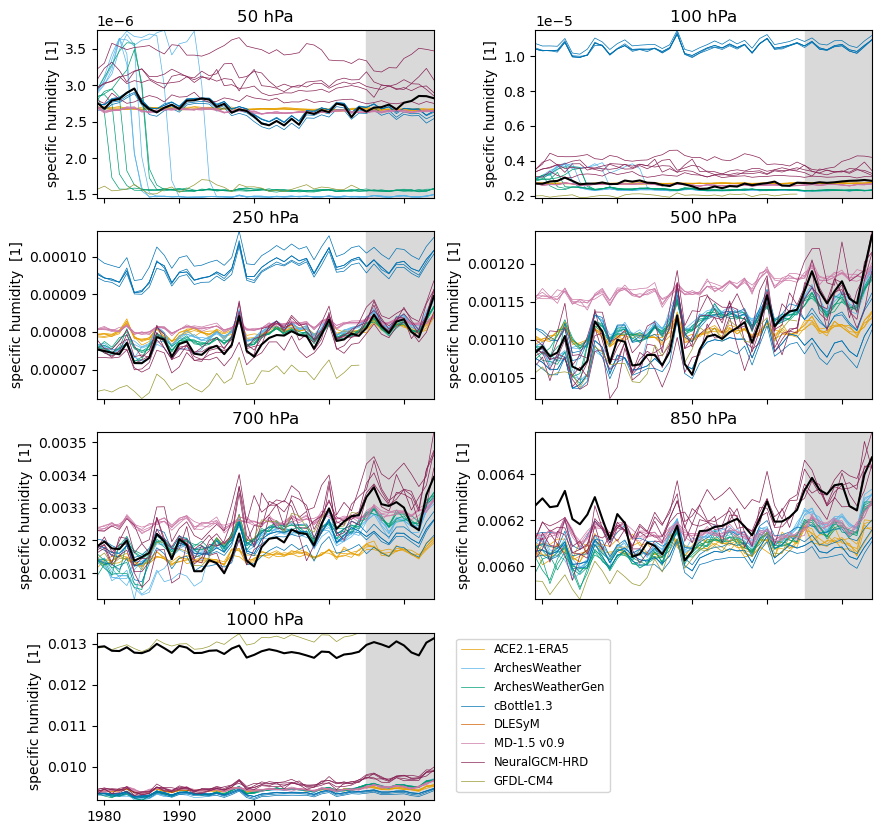

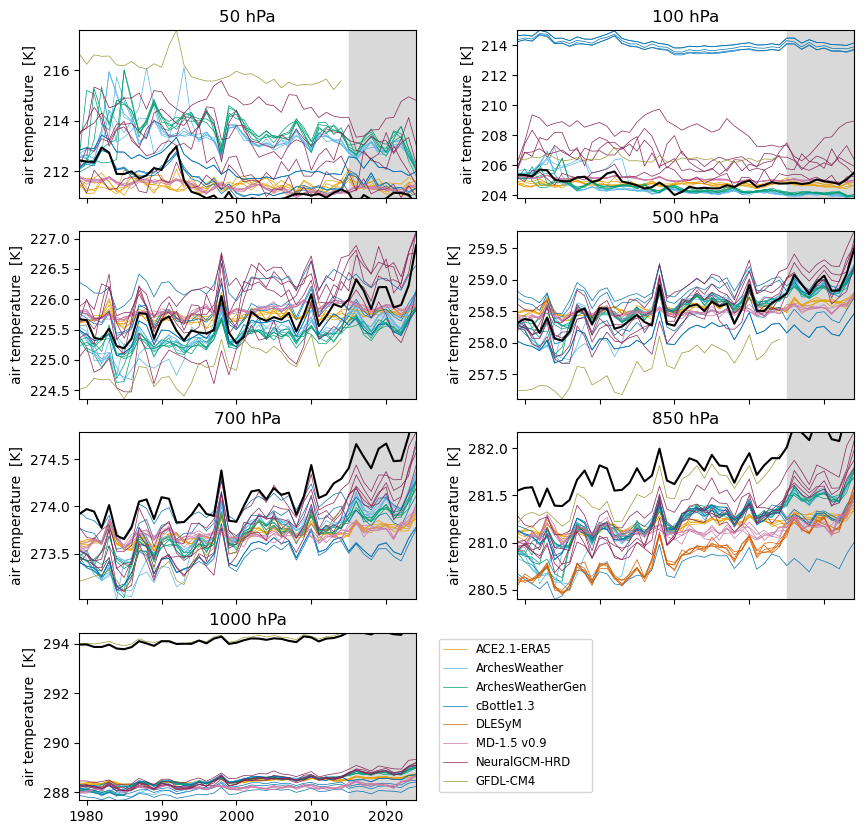

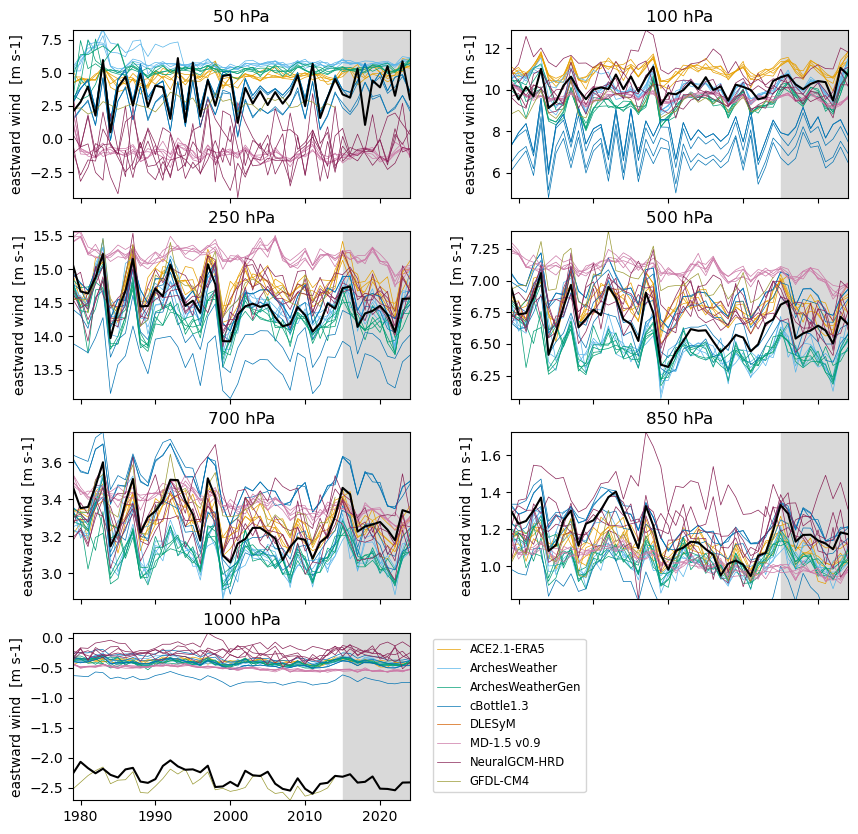

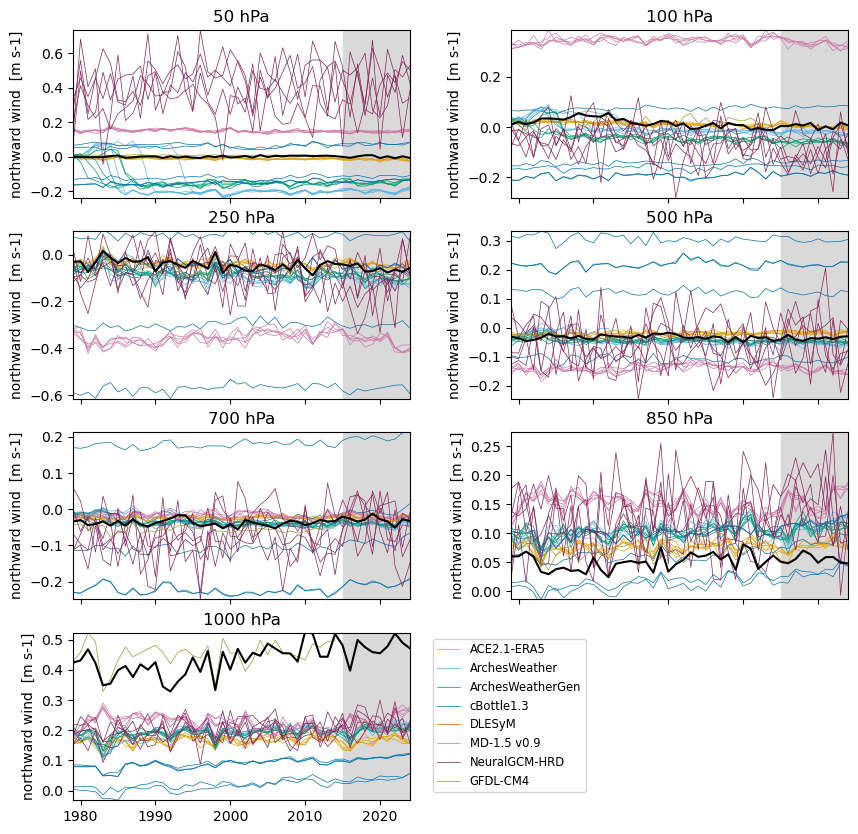

In [23]:
pressure_vars = [var for var in regridded_global_annual_means.data_vars if "plev" in regridded_global_annual_means[var].dims]
for pressure_var in pressure_vars:
    fig, axes = plt.subplots(
        nrows=int(np.ceil(regridded_global_annual_means.sizes["plev"] / 2)),
        ncols=2,
        figsize=(10, 10),
        sharex=True,
        sharey=False,
    )
    for ax, plev in zip(axes.flatten(), regridded_global_annual_means.coords["plev"]):
        handles = []
        for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
            h = regridded_global_annual_means[pressure_var].sel(plev=plev, experiment_submission=experiment_submission).plot(
                ax=ax, hue='realization', color=CATEGORICAL_COLORS[i], add_legend=False, lw=0.5
            )
            handles.append(h[0])
        global_annual_mean_era5[pressure_var].sel(plev=plev).plot(ax=ax, color='k', lw=1.5)
        scale_data = regridded_global_annual_means[pressure_var].sel(plev=plev).drop_sel(realization=2)
        ylim = scale_data.min().item(), scale_data.max().item()
        xlim = 1979, 2024
        ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
        ax.set_xlim([xlim[0], xlim[1]])
        ax.set_ylim([ylim[0], ylim[1]])
        ax.set_title(f"{str(int(plev.item() / 100))} hPa")
        ax.set_ylabel(
            f"{regridded_global_annual_means[pressure_var].attrs.get('long_name', pressure_var)} "
            f" [{regridded_global_annual_means[pressure_var].attrs.get('units', '-')}]"
        )
        ax.set_xlabel(None)
        if ax is axes.flatten()[-2]:
            axes.flatten()[-1].set_axis_off()
            ax.legend(
                handles,
                regridded_global_annual_means.coords["experiment_submission"].values,
                bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small'
            )
    fig.subplots_adjust(wspace=0.3)
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"trend_series_{pressure_var}.png"), bbox_inches='tight')

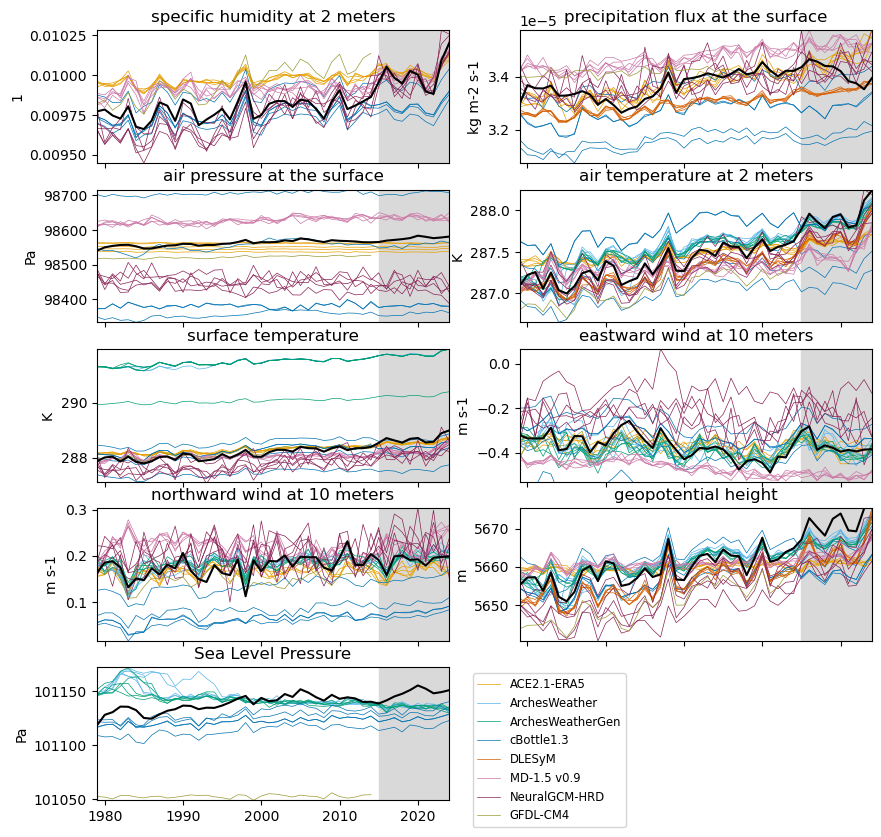

In [24]:
surface_vars = [var for var in regridded_global_annual_means.data_vars if "plev" not in regridded_global_annual_means[var].dims]
fig, axes = plt.subplots(nrows=int(np.ceil(len(surface_vars) / 2)), ncols=2, figsize=(10, 10), sharex=True, sharey=False)
for ax, surface_var in zip(axes.flatten(), surface_vars):
    handles = []
    for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
        h = regridded_global_annual_means[surface_var].sel(experiment_submission=experiment_submission).plot(
            ax=ax, hue='realization', color=CATEGORICAL_COLORS[i], add_legend=False, lw=0.5
        )
        handles.append(h[0])
    if surface_var in global_annual_mean_era5.data_vars:
        global_annual_mean_era5[surface_var].plot(ax=ax, color='k', lw=1.5)
    scale_data = regridded_global_annual_means[surface_var].drop_sel(realization=2)
    ylim = scale_data.min().item(), scale_data.max().item()
    xlim = 1979, 2024
    ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xlim([xlim[0], xlim[1]])
    ax.set_ylim([ylim[0], ylim[1]])
    ax.set_ylabel(f"{regridded_global_annual_means[surface_var].attrs.get('units', '-')}")
    ax.set_title(f"{regridded_global_annual_means[surface_var].attrs.get('long_name', surface_var)}")
    ax.set_xlabel(None)
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(
            handles,
            regridded_global_annual_means.coords["experiment_submission"].values,
            bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small'
        )
fig.patch.set_alpha(0.0)
fig.savefig(os.path.join(OUTDIR, f"trend_series_surface_vars.png"), bbox_inches='tight')

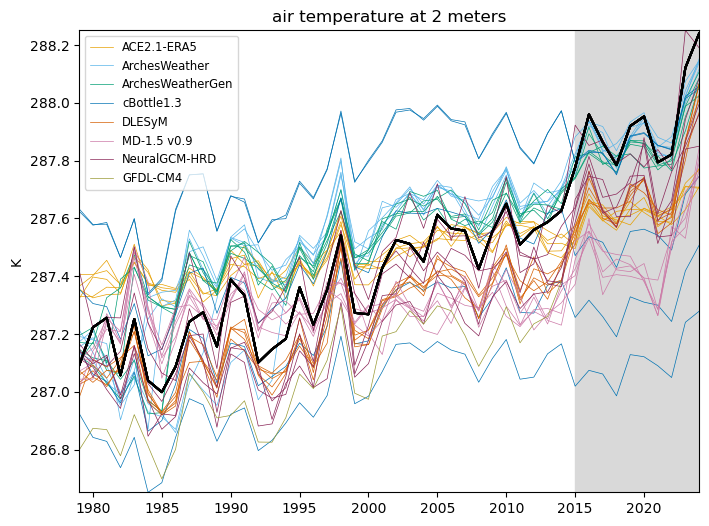

In [25]:
# TMP2m only version of global+annual series plot
fig, ax = plt.subplots(figsize=(8, 6))
handles = []
for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
    h = regridded_global_annual_means['tas'].sel(experiment_submission=experiment_submission).plot(
        ax=ax, hue='realization', color=CATEGORICAL_COLORS[i], add_legend=False, lw=0.5
    )
    handles.append(h[0])
    global_annual_mean_era5['tas'].plot(ax=ax, color='k', lw=1.5)
scale_data = regridded_global_annual_means['tas']
ylim = scale_data.min().item(), scale_data.max().item()
xlim = 1979, 2024
ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
ax.set_xlim([xlim[0], xlim[1]])
ax.set_ylim([ylim[0], ylim[1]])
ax.set_ylabel(f"{regridded_global_annual_means['tas'].attrs.get('units', '-')}")
ax.set_title(f"{regridded_global_annual_means['tas'].attrs.get('long_name', surface_var)}")
ax.set_xlabel(None)
ax.legend(
    handles,
    regridded_global_annual_means.coords["experiment_submission"].values,
    fontsize='small',
)
fig.patch.set_alpha(0.0)
fig.savefig(os.path.join(OUTDIR, f"trend_series_tas.png"), bbox_inches='tight')

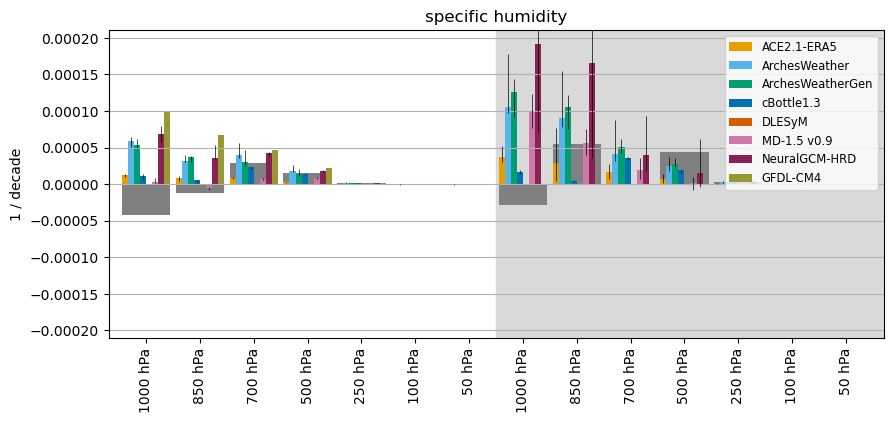

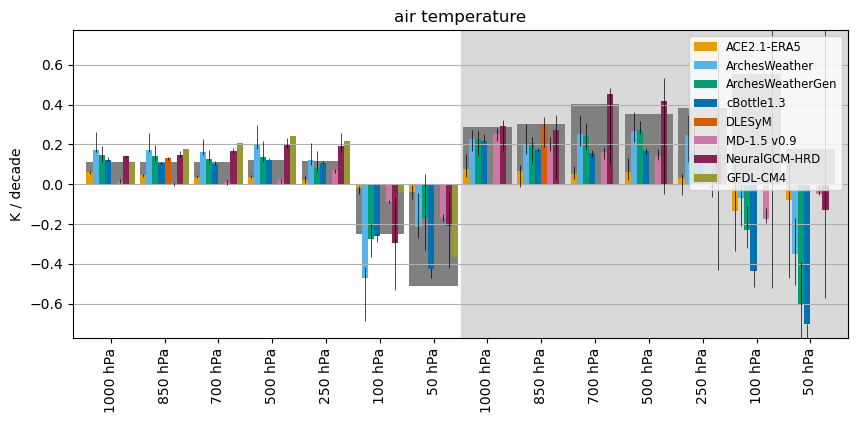

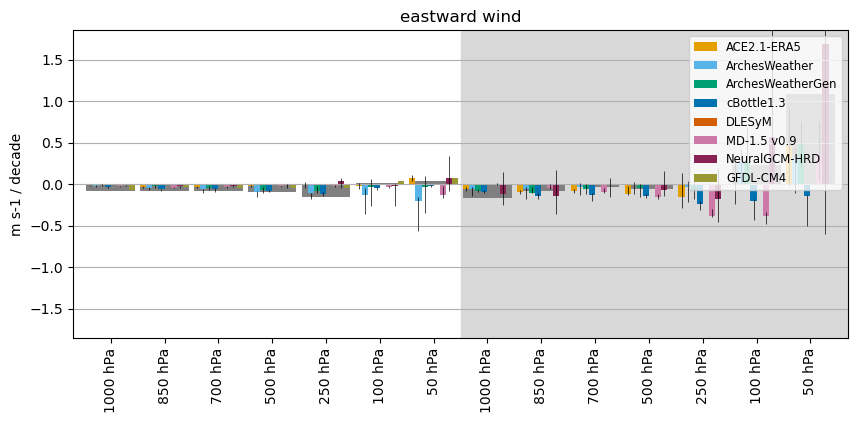

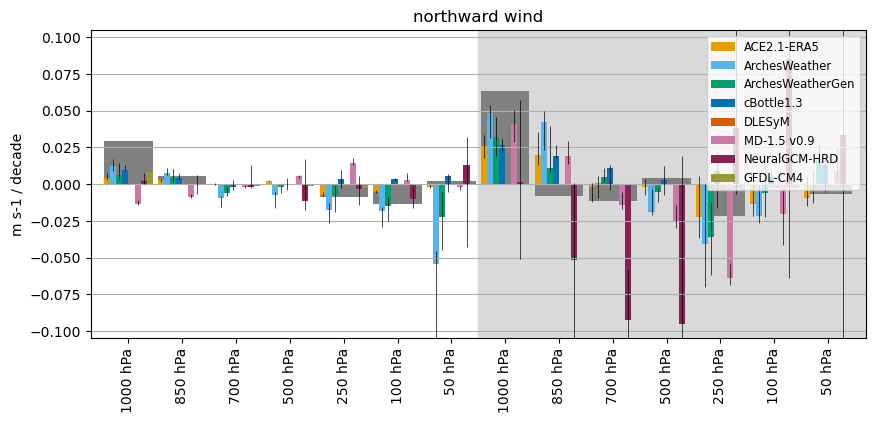

In [26]:
for pressure_var in pressure_vars:
    fig, ax = plt.subplots(figsize=(10, 4))
    trends = (
        global_mean_trend[pressure_var].transpose('time_period', 'plev', 'experiment_submission', 'realization')
    )
    lowest, median, highest = (
        trends.min('realization').to_dataframe().unstack(),
        trends.median('realization').to_dataframe().unstack(),
        trends.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax, legend=False, color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    (
        global_mean_trend_era5[pressure_var]
        .to_dataframe()
        .plot.bar(width=0.9, ax=ax, color='#808080', zorder=-1, legend=False)
    )
    ax.legend(trends.experiment_submission.values, fontsize='small')
    ax.grid(axis='y')
    xlim = ax.get_xlim()
    yscale = 1.1 * max([
        np.abs(trends.median('realization')).max().item(),
        np.abs(global_mean_trend_era5[pressure_var]).max().item(),
    ])
    ylim = -yscale, yscale
    ax.fill_between([(xlim[0] + xlim[1]) / 2, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('')
    ax.set_xticklabels([f"{str(round(ind[1]/100))} hPa" for ind in median.index])
    ax.set_ylabel(f"{regridded_global_annual_means[pressure_var].attrs.get('units', pressure_var)} / decade")
    ax.set_title(f"{regridded_global_annual_means[pressure_var].attrs.get('long_name', pressure_var)}")
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"trend_mean_{pressure_var}.png"), bbox_inches="tight")

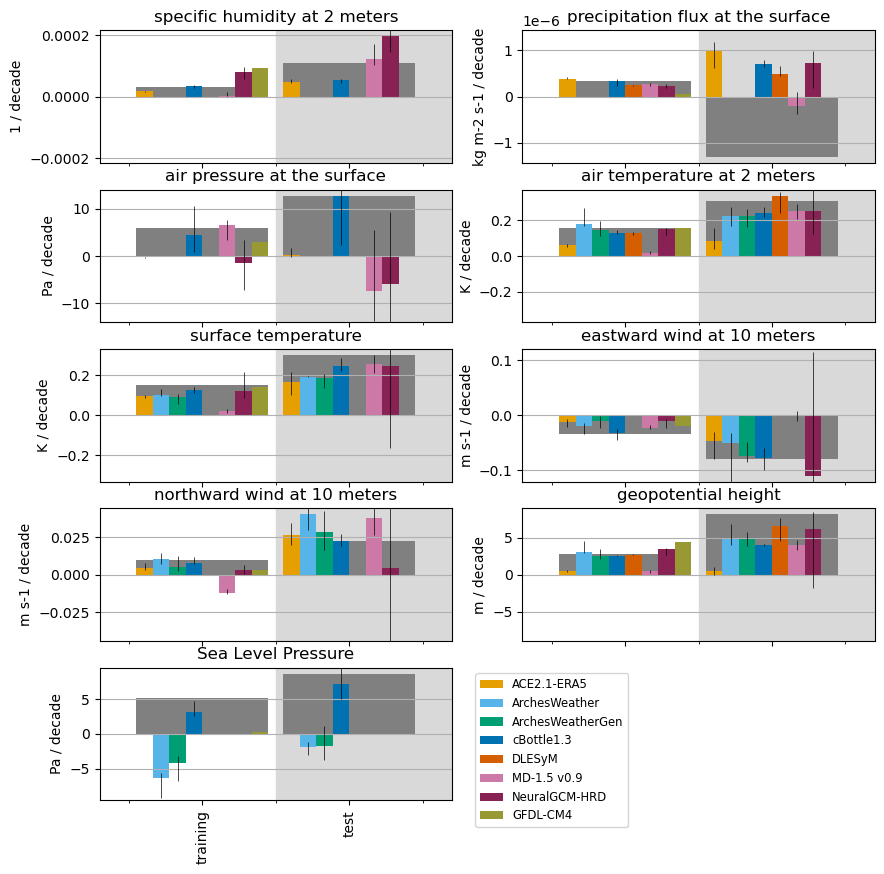

In [27]:
fig, axes = plt.subplots(sharex=True, ncols=2, nrows=int(np.ceil(len(surface_vars) / 2)), figsize=(10, 10))
for ax, surface_var in zip(axes.flatten(), surface_vars):
    trends = (
        global_mean_trend[surface_var].transpose('time_period', 'experiment_submission', 'realization')
    )
    lowest, median, highest = (
        trends.min('realization').to_dataframe().unstack(),
        trends.median('realization').to_dataframe().unstack(),
        trends.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax, legend=False, color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if surface_var in global_mean_trend_era5.data_vars:
        (
            global_mean_trend_era5[surface_var]
            .to_dataframe().unstack()
            .plot.bar(width=0.9, ax=ax, color='#808080', zorder=-1, legend=False)
        )
    ax.grid(axis='y')
    xlim = ax.get_xlim()
    yscale = 1.1 * max([
        np.abs(trends.median('realization')).max().item(),
        np.abs(global_mean_trend_era5[surface_var]).max().item(),
    ])
    ylim = -yscale, yscale
    ax.fill_between([(xlim[0] + xlim[1]) / 2, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('')
    ax.set_xticklabels([time_period for time_period in global_mean_trend['time_period'].values])
    ax.set_ylabel(f"{regridded_global_annual_means[surface_var].attrs.get('units', surface_var)} / decade")
    ax.set_title(f"{regridded_global_annual_means[surface_var].attrs.get('long_name', surface_var)}")
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(
            [patch for patch in ax.patches[::2]],
            regridded_global_annual_means.coords["experiment_submission"].values,
            bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small'
        )
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"trend_mean_surface_variables.png"), bbox_inches="tight")

## Manuscript Figures

In [28]:
import matplotlib.ticker as mticker
import textwrap
import re

MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

MANUSCRIPT_DPI = 300
MANUSCRIPT_FORMAT = 'eps'

# GMD / EGU figure width limits (in inches)
GMD_SINGLE_COL_IN = 84 / 25.4   # 84 mm
GMD_DOUBLE_COL_IN = 174 / 25.4  # 174 mm
GMD_MAX_HEIGHT_IN = 170 / 25.4  # 170 mm — leave room for caption

def ms_savefig(fig, name):
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    fig.savefig(os.path.join(MANUSCRIPT_DIR, f'{name}.png'), dpi=MANUSCRIPT_DPI, format='png')
    print(f'Saved {path}')


def _model_title(label, width=16):
    """Wrap only at spaces; never break hyphenated tokens mid-word."""
    return textwrap.fill(label, width=width, break_long_words=False, break_on_hyphens=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/trend_series_tas_ens_false.eps


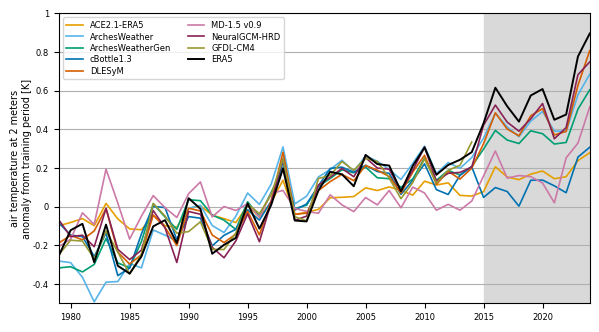

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/trend_series_tas_ens_true.eps


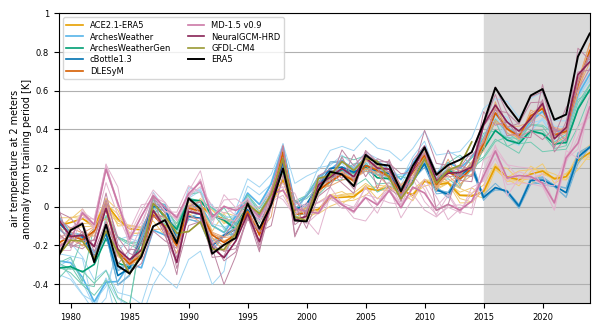

In [29]:
# Manuscript Figure: global annual mean 2m temperature time series
LABEL_FS = 7

fig_width  = GMD_DOUBLE_COL_IN
fig_height = fig_width * 0.55  # ~landscape ratio, stays well under GMD max height
plot_anomaly = True


for plot_ensemble_members in [False, True]:
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    handles = []
    for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
        da = regridded_global_annual_means['tas'].sel(experiment_submission=experiment_submission)
        da_era5 = global_annual_mean_era5['tas']
        if plot_anomaly:
            training_years = (1979, 2014)
            da = da - da.sel(year=slice(*training_years)).mean('year')
            da_era5 = da_era5 - da_era5.sel(year=slice(*training_years)).mean('year')
            ylim = -0.5, 1.0
        else:
            ylim = scale_data.min().item(), scale_data.max().item()
        if plot_ensemble_members:
            # thin, translucent lines for individual ensemble members
            h = da.plot(ax=ax, hue='realization', color=['#f1ca73', '#a2d6f3', '#73cab2', '#73b1d5', '#e8a673', '#e3b5cf', '#be85a2', '#c7c78f'][i],
                        add_legend=False, lw=0.7)
        # thick opaque line for ensemble mean
        hm = da.mean('realization').plot(ax=ax, color=CATEGORICAL_COLORS[i], lw=1.2, add_legend=False)
        handles.append(hm[0])
    era5_h = da_era5.plot(ax=ax, color='k', lw=1.4, label='ERA5')

    xlim = 1979, 2024
    ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xlim([xlim[0], xlim[1]])
    ax.set_ylim([ylim[0], ylim[1]])
    ax.grid(axis='y')

    long_name = regridded_global_annual_means['tas'].attrs.get('long_name', '2m air temperature').lower()
    units = regridded_global_annual_means['tas'].attrs.get('units', 'K')
    if plot_anomaly:
        label = f"{long_name}\nanomaly from training period [{units}]"
    else:
        label = f"{long_name} [{units}]"
    ax.set_ylabel(label, fontsize=LABEL_FS, labelpad=1)
    ax.set_xlabel(None)
    ax.tick_params(labelsize=LABEL_FS - 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

    exp_names = list(regridded_global_annual_means.coords["experiment_submission"].values) + ['ERA5']
    handles = handles + [era5_h[0]]
    ax.legend(
        handles,
        exp_names,
        fontsize=LABEL_FS - 1,
        loc='upper left',
        frameon=True,
        borderpad=0.4,
        labelspacing=0.3,
        ncol=2,
    )

    fig.patch.set_alpha(0.0)
    # fig.set_facecolor('#faf2e9') # for Ai2 comms blog post 
    ms_savefig(fig, f'trend_series_tas_ens_{str(plot_ensemble_members).lower()}')
    plt.show()

Saved ./figures/manuscript_figures/trend_bar_surface_and_plev.eps


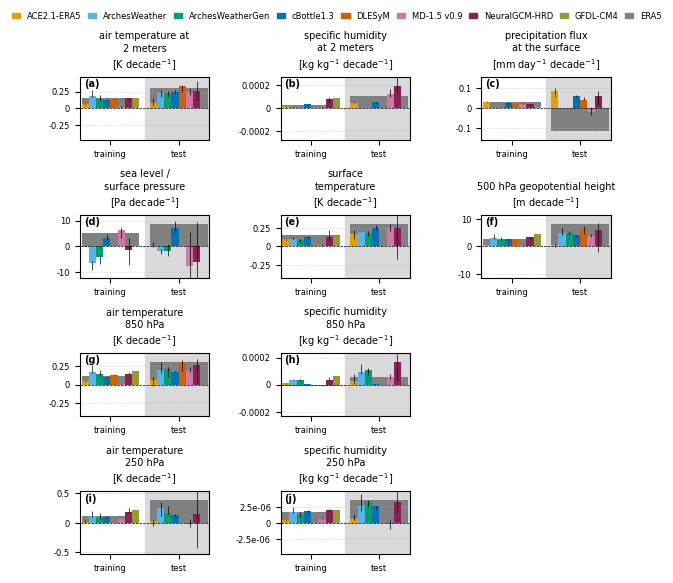

In [30]:
# Manuscript Figure: global mean decadal trend bar chart (surface + key pressure levels)
# Variable set and ordering matches E1 RMSB bar chart.

LABEL_FS = 7

# ── Variable ordering: match E1 RMSB chart ───────────────────────────────
SURF_VARS_ORDER = ['tas', 'huss', 'pr', 'psl', 'ts', 'zg']   # ps merged into psl; winds removed
PLEV_VARS_ORDER = ['ta', 'hus']   # winds removed
PLEV_850  = 85000.
PLEV_250  = 25000.
PLEV_ZG   = 50000.
PLEV_ROWS = [(PLEV_850, '850'), (PLEV_250, '250')]

# Filter to vars present in the dataset
_avail = set(global_mean_trend.data_vars)
surf_vars_plot = [v for v in SURF_VARS_ORDER if v in _avail or v == 'psl']
plev_vars_plot = [v for v in PLEV_VARS_ORDER if v in _avail]

N_COLS = 3
n_surf_rows = 2   # 6 surface vars in 2 rows × 3 cols
n_plev_rows = len(PLEV_ROWS)
n_rows = n_surf_rows + n_plev_rows   # 4 rows total

fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(n_rows * 1.55, GMD_MAX_HEIGHT_IN)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=N_COLS,
    figsize=(fig_width, fig_height),
    gridspec_kw=dict(hspace=1.2, wspace=0.55),
)
fig.subplots_adjust(top=0.88)   # leave room for top legend

letter_idx = 0
letters = [f'({chr(ord("a") + i)})' for i in range(26)]

def panel_letter(ax, letter):
    ax.text(0.03, 0.97, letter, transform=ax.transAxes,
            fontsize=LABEL_FS, fontweight='bold', va='top', ha='left')

def plot_trend_panel(ax, var, trends_var, era5_trends_var, title, pr_scale=1.0):
    trends_scaled = trends_var * pr_scale
    era5_scaled   = era5_trends_var * pr_scale if era5_trends_var is not None else None

    lowest  = trends_scaled.min('realization').to_dataframe().unstack()
    median  = trends_scaled.median('realization').to_dataframe().unstack()
    highest = trends_scaled.max('realization').to_dataframe().unstack()

    median.plot.bar(width=0.85, 
        ax=ax, legend=False, color=CATEGORICAL_COLORS,
        yerr=np.concat(
            [(median - lowest).values.T[:, None, :],
             (highest - median).values.T[:, None, :]],
            axis=1,
        ),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if era5_scaled is not None:
        era5_scaled.to_dataframe().unstack().plot.bar(width=0.85, 
            ax=ax, color='#808080', zorder=-1, legend=False
        )

    ax.set_axisbelow(True)
    vals = [float(np.nanmax(np.abs(median).values))]
    if era5_scaled is not None:
        vals.append(float(np.nanmax(np.abs(era5_scaled).values)))
    yscale = 1.4 * max(v for v in vals if np.isfinite(v)) if any(np.isfinite(v) and v > 0 for v in vals) else 1.0
    ylim = -yscale, yscale
    xlim = ax.get_xlim()

    xticks = ax.get_xticks()
    shade_x = (xticks[0] + xticks[-1]) / 2 if len(xticks) >= 2 else xlim[1] / 2
    ax.fill_between(
        [shade_x, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]],
        color='#d9d9d9', zorder=-2,
    )
    ax.set_xlim(-0.45, 1.45)
    ax.set_ylim(ylim)
    ax.set_xlabel('')
    ax.set_xticklabels([tp for tp in global_mean_trend['time_period'].values],
                       fontsize=LABEL_FS - 1, rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
    ax.set_ylabel('')
    ax.axhline(0, color='k', lw=0.5, ls='--', zorder=1)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='#b3b3b3')
    ax.set_title(title, fontsize=LABEL_FS, linespacing=1.3)

# Merge ps into psl: prefer psl per model, fall back to ps
if 'psl' in global_mean_trend.data_vars and 'ps' in global_mean_trend.data_vars:
    global_mean_trend = global_mean_trend.assign(
        psl=global_mean_trend['psl'].fillna(global_mean_trend['ps'])
    )
elif 'ps' in global_mean_trend.data_vars:
    global_mean_trend = global_mean_trend.assign(psl=global_mean_trend['ps'])
if 'psl' not in global_mean_trend_era5.data_vars and 'ps' in global_mean_trend_era5.data_vars:
    global_mean_trend_era5 = global_mean_trend_era5.assign(psl=global_mean_trend_era5['ps'])

def _advance_to_next_row(ax_flat, ax_idx, N_COLS):
    next_row = ((ax_idx - 1) // N_COLS + 1) * N_COLS
    for i in range(ax_idx, next_row):
        ax_flat[i].set_axis_off()
    return next_row

ax_flat = axes.flatten()
ax_idx  = 0

# ── Surface panels (2 rows × 4 cols) ─────────────────────────────────────
for var in surf_vars_plot:
    ax = ax_flat[ax_idx]

    _tv = global_mean_trend[var]
    base_units   = regridded_global_annual_means[var].attrs.get('units', var)
    raw_longname = _tv.attrs.get('long_name',
                   regridded_global_annual_means[var].attrs.get('long_name', var))
    raw_units    = f'{base_units} decade$^{{-1}}$'

    pr_scale = 1.0
    if var == 'pr':
        raw_units = r'mm day$^{-1}$ decade$^{-1}$'
        pr_scale  = 86400.
    if raw_units in ('1', '1 decade$^{-1}$'):
        raw_units = r'kg kg$^{-1}$ decade$^{-1}$'

    long_name = textwrap.fill(raw_longname.lower(), width=18)
    if var == 'psl':
        long_name = textwrap.fill('sea level / surface pressure', width=18)
    if var == 'zg':
        long_name = textwrap.fill(raw_longname.lower(), width=22)  # wider so name stays 1 line
        title = f'500 hPa {long_name}\n[{raw_units}]'
    else:
        title = f'{long_name}\n[{raw_units}]'

    era5_var = global_mean_trend_era5[var] if var in global_mean_trend_era5.data_vars else None
    _zg_era5 = era5_var
    if var == 'zg' and era5_var is not None:
        if 'plev' in era5_var.dims:
            _zg_era5 = era5_var.sel(plev=PLEV_ZG).drop_vars('plev')
        elif 'plev' in era5_var.coords:
            _zg_era5 = era5_var.drop_vars('plev')

    _trends = global_mean_trend[var]
    if var == 'zg':
        if 'plev' in _trends.dims:
            _trends = _trends.sel(plev=PLEV_ZG).drop_vars('plev')
        elif 'plev' in _trends.coords:
            _trends = _trends.drop_vars('plev')

    plot_trend_panel(
        ax, var,
        _trends.transpose('time_period', 'experiment_submission', 'realization'),
        _zg_era5.transpose('time_period') if _zg_era5 is not None else None,
        title, pr_scale=pr_scale,
    )
    panel_letter(ax, letters[letter_idx])
    letter_idx += 1
    ax_idx += 1

ax_idx = _advance_to_next_row(ax_flat, ax_idx, N_COLS)

# ── Pressure-level panels (850 and 250 hPa) ───────────────────────────────
for plev, plev_label in PLEV_ROWS:
    for var in plev_vars_plot:
        ax = ax_flat[ax_idx]

        _tv = global_mean_trend[var].sel(plev=plev).drop_vars('plev')
        base_units   = regridded_global_annual_means[var].attrs.get('units', var)
        raw_longname = _tv.attrs.get('long_name',
                       regridded_global_annual_means[var].attrs.get('long_name', var))
        raw_units    = f'{base_units} decade$^{{-1}}$'
        if raw_units in ('1', '1 decade$^{-1}$'):
            raw_units = r'kg kg$^{-1}$ decade$^{-1}$'

        long_name = textwrap.fill(raw_longname.lower(), width=18)
        title = f'{long_name}\n{plev_label} hPa\n[{raw_units}]'

        trends_plev = (
            global_mean_trend[var]
            .sel(plev=plev).drop_vars('plev')
            .transpose('time_period', 'experiment_submission', 'realization')
        )
        era5_plev = (
            global_mean_trend_era5[var].sel(plev=plev).drop_vars('plev').transpose('time_period')
            if var in global_mean_trend_era5.data_vars else None
        )

        plot_trend_panel(ax, var, trends_plev, era5_plev, title)
        panel_letter(ax, letters[letter_idx])
        letter_idx += 1
        ax_idx += 1
    ax_idx = _advance_to_next_row(ax_flat, ax_idx, N_COLS)

# ── Top legend (horizontal, above panels) ────────────────────────────────
exp_names = list(regridded_global_annual_means.coords["experiment_submission"].values)
bar_handles = [
    plt.Rectangle((0, 0), 1, 1, color=CATEGORICAL_COLORS[i])
    for i in range(len(exp_names))
]
era5_handle = plt.Rectangle((0, 0), 1, 1, color='#808080')
fig.legend(
    bar_handles + [era5_handle],
    exp_names + ['ERA5'],
    fontsize=LABEL_FS - 1,
    loc='upper center',
    ncol=len(exp_names) + 1,
    bbox_to_anchor=(0.5, 0.995),
    frameon=False,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.0,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'trend_bar_surface_and_plev')
plt.show()

Saved ./figures/manuscript_figures/trend_map_1deg.eps


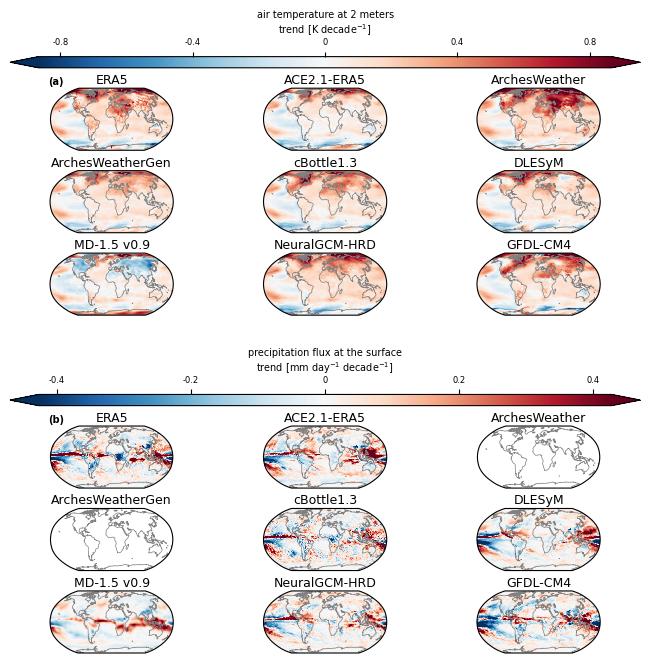

In [31]:
# Manuscript Figure: raw decadal trends — ERA5 and all models, 1° grid, training period

import textwrap
import matplotlib.ticker as mticker
import os

GMD_DOUBLE_COL_IN = 174 / 25.4
GMD_MAX_HEIGHT_IN = 170 / 25.4
LABEL_FS          = 7
VAR_SCALE         = {'pr': 86400.}
VAR_UNITS         = {
    'tas': r'K decade$^{-1}$',
    'pr':  r'mm day$^{-1}$ decade$^{-1}$',
}
OUTDIR       = os.environ.get('AIMIP_FIGURES_DIR', './figures')
MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

def _ms_savefig(fig, name):
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    fig.savefig(os.path.join(MANUSCRIPT_DIR, f'{name}.png'), dpi=MANUSCRIPT_DPI, format='png')
    print(f'Saved {path}')

vars_to_plot = ['tas', 'pr']
tp           = 'training'
n_cols       = 3
exp_names    = list(regridded_trend_1deg.experiment_submission.values)
n_panels     = 1 + len(exp_names)
n_map_rows   = (n_panels + n_cols - 1) // n_cols

CB_H  = 0.60
SEP_H = 0.20
map_h = (GMD_DOUBLE_COL_IN / n_cols) / 2.1
height_ratios = [CB_H] + [1.0] * n_map_rows + [SEP_H] + [CB_H] + [1.0] * n_map_rows
n_gs_rows     = len(height_ratios)

fig_height = min(
    map_h * (sum(height_ratios) + 0.40 * (n_gs_rows - 1)) + 0.3,
    GMD_MAX_HEIGHT_IN,
)
fig = plt.figure(figsize=(GMD_DOUBLE_COL_IN, fig_height))
gs  = fig.add_gridspec(
    nrows=n_gs_rows, ncols=n_cols,
    height_ratios=height_ratios,
    hspace=0.40, wspace=0.05,
)
fig.subplots_adjust(left=0.05, right=0.97, top=0.94, bottom=0.01)

# vlim: 98th percentile of abs values across ERA5 and all models, per variable
vlim = {}
for var in vars_to_plot:
    scale      = VAR_SCALE.get(var, 1.0)
    era5_vals  = regridded_trend_era5_1deg[var].sel(time_period=tp).values * scale
    model_vals = regridded_trend_1deg[var].isel(realization=0).sel(time_period=tp).values * scale
    all_vals   = np.concatenate([era5_vals.ravel(), model_vals.ravel()])
    vlim[var]  = float(np.nanquantile(np.abs(all_vals), 0.98))

var_gs_offsets = [0, n_map_rows + 1 + 1]
block_letters  = ['a', 'b']

for vi, var in enumerate(vars_to_plot):
    scale     = VAR_SCALE.get(var, 1.0)
    units_str = VAR_UNITS[var]
    long_name = regridded_trend_era5_1deg[var].attrs.get('long_name', var).lower()

    gs_offset   = var_gs_offsets[vi]
    cb_gs_row   = gs_offset
    map_gs_rows = list(range(gs_offset + 1, gs_offset + 1 + n_map_rows))

    ticks_all = mticker.MaxNLocator(nbins=5, symmetric=True).tick_values(-vlim[var], vlim[var])
    ticks     = ticks_all[(ticks_all >= -vlim[var]) & (ticks_all <= vlim[var])]

    all_labels = ['ERA5'] + exp_names
    all_axes   = []
    for panel_idx in range(len(all_labels)):
        map_row_idx = panel_idx // n_cols
        col         = panel_idx % n_cols
        ax = fig.add_subplot(gs[map_gs_rows[map_row_idx], col], projection=ccrs.Robinson())
        ax.coastlines(color='gray', linewidth=0.5)
        all_axes.append(ax)

    # ERA5
    era5_data = regridded_trend_era5_1deg[var].sel(time_period=tp) * scale
    im = era5_data.plot(
        ax=all_axes[0], transform=ccrs.PlateCarree(),
        cmap='RdBu_r', vmin=-vlim[var], vmax=vlim[var],
        add_colorbar=False, add_labels=False, rasterized=True,
    )

    # Models
    for i, exp in enumerate(exp_names):
        ax   = all_axes[i + 1]
        data = regridded_trend_1deg[var].isel(realization=0).sel(
            time_period=tp, experiment_submission=exp
        ) * scale
        if not bool(data.isnull().all()):
            data.plot(
                ax=ax, transform=ccrs.PlateCarree(),
                cmap='RdBu_r', vmin=-vlim[var], vmax=vlim[var],
                add_colorbar=False, add_labels=False, rasterized=True,
            )
        else:
            ax.set_global()

    # One block letter above-left of ERA5 panel; model name titles on all panels
    for i, (ax, label) in enumerate(zip(all_axes, all_labels)):
        if i == 0:
            ax.text(-0.02, 1.02, f'({block_letters[vi]})',
                    transform=ax.transAxes, fontsize=LABEL_FS, fontweight='bold',
                    va='bottom', ha='left', clip_on=False)
        title = 'ERA5' if label == 'ERA5' else textwrap.fill(
            label, width=20, max_lines=2, break_long_words=False, break_on_hyphens=False
        )
        ax.set_title(title, fontsize=LABEL_FS + 2, pad=3)

    # Single colorbar: bar at bottom of CB row, ticks+title on top (mirrors plot_trend_bias_map)
    cb_ax = fig.add_subplot(gs[cb_gs_row, :])
    cb_ax.set_visible(False)
    bar_h_frac = 0.30
    fig.canvas.draw()
    cb_pos  = cb_ax.get_position()
    cbar_ax = fig.add_axes([
        cb_pos.x0, cb_pos.y0, cb_pos.width, cb_pos.height * bar_h_frac,
    ])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                        extend='both', ticks=ticks)
    cbar.ax.xaxis.tick_top()
    cbar.ax.set_title(
        f'{long_name}\ntrend [{units_str}]',
        size=LABEL_FS, pad=2,
    )
    cbar.ax.tick_params(labelsize=LABEL_FS - 1)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

_ms_savefig(fig, 'trend_map_1deg')

## Appendix Figures

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_trend_1deg_plev_ta.eps


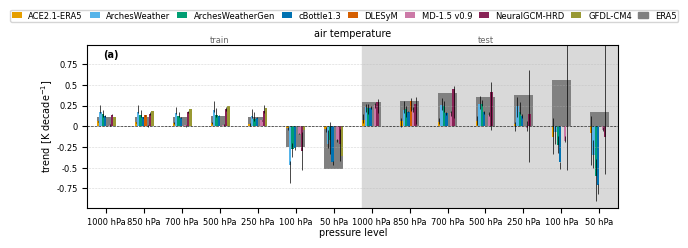

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_trend_1deg_plev_hus.eps


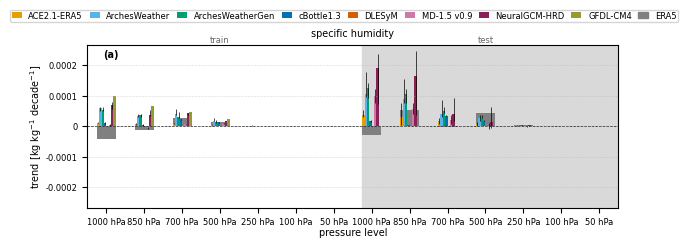

In [32]:
# Appendix Figures: GMD-styled pressure-level trend profiles for ta and hus (1° data)
# One figure per variable — same data as the exploratory pressure-level trend cells,
# but styled to manuscript conventions (LABEL_FS=7, ms_savefig, FuncFormatter).
# Uses global_mean_trend (1°, NeuralGCM-HRD included, NeuralGCM excluded).

import matplotlib.ticker as mticker
import textwrap

LABEL_FS = 7

_tick_fmt = mticker.FuncFormatter(lambda x, _: f'{x:g}')

for varname in ['ta', 'hus']:
    if varname not in global_mean_trend:
        continue

    trends = global_mean_trend[varname].transpose(
        'time_period', 'plev', 'experiment_submission', 'realization'
    )
    base_units   = regridded_global_annual_means[varname].attrs.get('units', varname)
    raw_longname = trends.attrs.get('long_name',
                   regridded_global_annual_means[varname].attrs.get('long_name', varname))
    raw_units = f'{base_units} decade$^{{-1}}$'
    if raw_units in ('1', '1 decade$^{-1}$'):
        raw_units = r'kg kg$^{-1}$ decade$^{-1}$'
    long_name = textwrap.fill(raw_longname.lower(), width=50)

    lowest  = trends.min('realization').to_dataframe().unstack()
    median  = trends.median('realization').to_dataframe().unstack()
    highest = trends.max('realization').to_dataframe().unstack()

    fig, ax = plt.subplots(figsize=(GMD_DOUBLE_COL_IN, 2.3))

    bars = median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat(
            [(median - lowest).values.T[:, None, :],
             (highest - median).values.T[:, None, :]],
            axis=1,
        ),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    legend_handles, _ = ax.get_legend_handles_labels()

    if varname in global_mean_trend_era5:
        era5_trends = global_mean_trend_era5[varname]
        (
            era5_trends
            .to_dataframe()
            .plot.bar(ax=ax, color='#808080', zorder=-1, legend=False)
        )
        era5_handle = plt.Rectangle((0, 0), 1, 1, color='#808080')

    xlim = ax.get_xlim()
    yscale = 1.4 * max(
        np.abs(median).max().max(),
        float(np.nanmax(np.abs(global_mean_trend_era5[varname].values))) if varname in global_mean_trend_era5 else 0.0,
    )
    if yscale == 0 or not np.isfinite(yscale):
        yscale = 1.0
    ylim = -yscale, yscale

    ax.fill_between(
        [xlim[1] / 2, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]],
        color='#d9d9d9', zorder=-2,
    )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.axhline(0, color='k', lw=0.5, ls='--', zorder=1)

    ax.set_xticklabels(
        [f'{round(ind[1] / 100)} hPa' for ind in median.index],
        rotation=0, fontsize=LABEL_FS - 1,
    )
    ax.set_xlabel('pressure level', fontsize=LABEL_FS, labelpad=1)
    ax.set_ylabel(f'trend [{raw_units}]', fontsize=LABEL_FS, labelpad=1)
    ax.yaxis.set_major_formatter(_tick_fmt)
    ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='#b3b3b3')
    ax.set_title(long_name, fontsize=LABEL_FS)

    ax.text(0.03, 0.97, '(a)', transform=ax.transAxes,
            fontsize=LABEL_FS, fontweight='bold', va='top', ha='left')

    # Train / test region labels
    mid_x = (xlim[0] + xlim[1]) / 2
    ax.text((xlim[0] + mid_x) / 2, ylim[1], 'train',
            ha='center', va='bottom', fontsize=LABEL_FS - 1, color='0.4')
    ax.text((mid_x + xlim[1]) / 2, ylim[1], 'test',
            ha='center', va='bottom', fontsize=LABEL_FS - 1, color='0.4')

    exp_names = list(global_mean_trend.coords['experiment_submission'].values)
    all_handles = legend_handles + ([era5_handle] if varname in global_mean_trend_era5 else [])
    all_labels  = exp_names + (['ERA5'] if varname in global_mean_trend_era5 else [])
    fig.legend(
        all_handles, all_labels,
        fontsize=LABEL_FS - 1,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(all_handles),
        frameon=True,
        borderpad=0.2,
        columnspacing=0.8,
        handlelength=1.2,
    )

    fig.patch.set_alpha(0.0)
    fig.subplots_adjust(top=0.82)
    ms_savefig(fig, f'app_trend_1deg_plev_{varname}')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved ./figures/manuscript_figures/app_trend_series_tas_2p8deg.eps


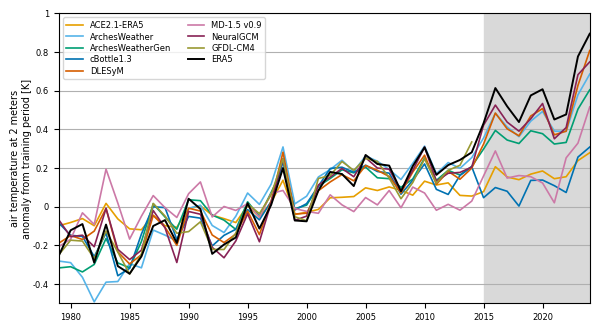

In [33]:
# Appendix Figure: global annual mean 2m temperature time series (2.8° data)
# NeuralGCM included, NeuralGCM-HRD excluded

LABEL_FS = 7

_gam_2p8deg = regridded_global_annual_means_2p8deg
_era5_gam_2p8deg = regridded_global_annual_mean_era5_2p8deg

fig_width  = GMD_DOUBLE_COL_IN
fig_height = fig_width * 0.55
plot_ensemble_members = False
plot_anomaly = True

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

handles = []
for i, experiment_submission in enumerate(_gam_2p8deg.coords["experiment_submission"]):
    da = _gam_2p8deg['tas'].sel(experiment_submission=experiment_submission)
    da_era5 = _era5_gam_2p8deg['tas']
    if plot_anomaly:
        training_years = (1979, 2014)
        da = da - da.sel(year=slice(*training_years)).mean('year')
        da_era5 = da_era5 - da_era5.sel(year=slice(*training_years)).mean('year')
        ylim = -0.5, 1.0
    else:
        ylim = _gam_2p8deg['tas'].min().item(), _gam_2p8deg['tas'].max().item()
    if plot_ensemble_members:
        da.plot(ax=ax, hue='realization', color=['#f1ca73', '#a2d6f3', '#73cab2', '#73b1d5', '#e8a673', '#e3b5cf', '#be85a2', '#c7c78f'][i],
                add_legend=False, lw=0.7)
    hm = da.mean('realization').plot(ax=ax, color=CATEGORICAL_COLORS[i], lw=1.2, add_legend=False)
    handles.append(hm[0])
era5_h = da_era5.plot(ax=ax, color='k', lw=1.4, label='ERA5')

xlim = 1979, 2024
ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
ax.set_xlim([xlim[0], xlim[1]])
ax.set_ylim([ylim[0], ylim[1]])
ax.grid(axis='y')

long_name = _gam_2p8deg['tas'].attrs.get('long_name', '2m air temperature').lower()
units = _gam_2p8deg['tas'].attrs.get('units', 'K')
if plot_anomaly:
    label = f"{long_name}\nanomaly from training period [{units}]"
else:
    label = f"{long_name} [{units}]"
ax.set_ylabel(label, fontsize=LABEL_FS, labelpad=1)
ax.set_xlabel(None)
ax.tick_params(labelsize=LABEL_FS - 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

exp_names = list(_gam_2p8deg.coords["experiment_submission"].values) + ['ERA5']
handles = handles + [era5_h[0]]
ax.legend(
    handles,
    exp_names,
    fontsize=LABEL_FS - 1,
    loc='upper left',
    frameon=True,
    borderpad=0.4,
    labelspacing=0.3,
    ncol=2,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'app_trend_series_tas_2p8deg')
plt.show()

Saved ./figures/manuscript_figures/app_trend_map_2p8deg.eps


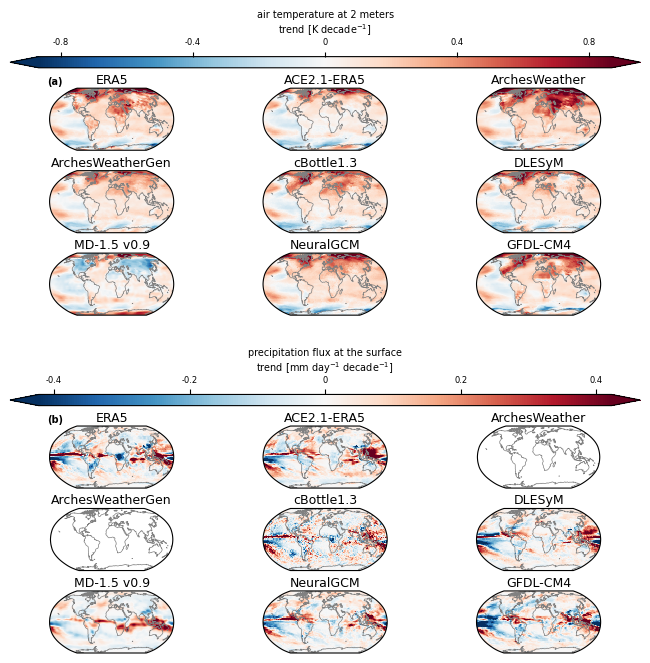

In [34]:
# Appendix Figure: raw decadal trends — ERA5 and all models, 2.8° grid, training period

import textwrap
import matplotlib.ticker as mticker
import os

GMD_DOUBLE_COL_IN = 174 / 25.4
GMD_MAX_HEIGHT_IN = 170 / 25.4
LABEL_FS          = 7
VAR_SCALE         = {'pr': 86400.}
VAR_UNITS         = {
    'tas': r'K decade$^{-1}$',
    'pr':  r'mm day$^{-1}$ decade$^{-1}$',
}
OUTDIR       = os.environ.get('AIMIP_FIGURES_DIR', './figures')
MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

def _ms_savefig(fig, name):
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    fig.savefig(os.path.join(MANUSCRIPT_DIR, f'{name}.png'), dpi=MANUSCRIPT_DPI, format='png')
    print(f'Saved {path}')

vars_to_plot = ['tas', 'pr']
tp           = 'training'
n_cols       = 3
exp_names    = list(regridded_trend_2p8deg.experiment_submission.values)
n_panels     = 1 + len(exp_names)
n_map_rows   = (n_panels + n_cols - 1) // n_cols

CB_H  = 0.60
SEP_H = 0.20
map_h = (GMD_DOUBLE_COL_IN / n_cols) / 2.1
height_ratios = [CB_H] + [1.0] * n_map_rows + [SEP_H] + [CB_H] + [1.0] * n_map_rows
n_gs_rows     = len(height_ratios)

fig_height = min(
    map_h * (sum(height_ratios) + 0.40 * (n_gs_rows - 1)) + 0.3,
    GMD_MAX_HEIGHT_IN,
)
fig = plt.figure(figsize=(GMD_DOUBLE_COL_IN, fig_height))
gs  = fig.add_gridspec(
    nrows=n_gs_rows, ncols=n_cols,
    height_ratios=height_ratios,
    hspace=0.40, wspace=0.05,
)
fig.subplots_adjust(left=0.05, right=0.97, top=0.94, bottom=0.01)

# vlim: 98th percentile of abs values across ERA5 and all models, per variable
vlim = {}
for var in vars_to_plot:
    scale      = VAR_SCALE.get(var, 1.0)
    era5_vals  = regridded_trend_era5_2p8deg[var].sel(time_period=tp).values * scale
    model_vals = regridded_trend_2p8deg[var].isel(realization=0).sel(time_period=tp).values * scale
    all_vals   = np.concatenate([era5_vals.ravel(), model_vals.ravel()])
    vlim[var]  = float(np.nanquantile(np.abs(all_vals), 0.98))

var_gs_offsets = [0, n_map_rows + 1 + 1]
block_letters  = ['a', 'b']

for vi, var in enumerate(vars_to_plot):
    scale     = VAR_SCALE.get(var, 1.0)
    units_str = VAR_UNITS[var]
    long_name = regridded_trend_era5_2p8deg[var].attrs.get('long_name', var).lower()

    gs_offset   = var_gs_offsets[vi]
    cb_gs_row   = gs_offset
    map_gs_rows = list(range(gs_offset + 1, gs_offset + 1 + n_map_rows))

    ticks_all = mticker.MaxNLocator(nbins=5, symmetric=True).tick_values(-vlim[var], vlim[var])
    ticks     = ticks_all[(ticks_all >= -vlim[var]) & (ticks_all <= vlim[var])]

    all_labels = ['ERA5'] + exp_names
    all_axes   = []
    for panel_idx in range(len(all_labels)):
        map_row_idx = panel_idx // n_cols
        col         = panel_idx % n_cols
        ax = fig.add_subplot(gs[map_gs_rows[map_row_idx], col], projection=ccrs.Robinson())
        ax.coastlines(color='gray', linewidth=0.5)
        all_axes.append(ax)

    # ERA5
    era5_data = regridded_trend_era5_2p8deg[var].sel(time_period=tp) * scale
    im = era5_data.plot(
        ax=all_axes[0], transform=ccrs.PlateCarree(),
        cmap='RdBu_r', vmin=-vlim[var], vmax=vlim[var],
        add_colorbar=False, add_labels=False, rasterized=True,
    )

    # Models
    for i, exp in enumerate(exp_names):
        ax   = all_axes[i + 1]
        data = regridded_trend_2p8deg[var].isel(realization=0).sel(
            time_period=tp, experiment_submission=exp
        ) * scale
        if not bool(data.isnull().all()):
            data.plot(
                ax=ax, transform=ccrs.PlateCarree(),
                cmap='RdBu_r', vmin=-vlim[var], vmax=vlim[var],
                add_colorbar=False, add_labels=False, rasterized=True,
            )
        else:
            ax.set_global()

    # One block letter above-left of ERA5 panel; model name titles on all panels
    for i, (ax, label) in enumerate(zip(all_axes, all_labels)):
        if i == 0:
            ax.text(-0.02, 1.02, f'({block_letters[vi]})',
                    transform=ax.transAxes, fontsize=LABEL_FS, fontweight='bold',
                    va='bottom', ha='left', clip_on=False)
        title = 'ERA5' if label == 'ERA5' else textwrap.fill(
            label, width=20, max_lines=2, break_long_words=False, break_on_hyphens=False
        )
        ax.set_title(title, fontsize=LABEL_FS + 2, pad=3)

    # Single colorbar: bar at bottom of CB row, ticks+title on top (mirrors plot_trend_bias_map)
    cb_ax = fig.add_subplot(gs[cb_gs_row, :])
    cb_ax.set_visible(False)
    bar_h_frac = 0.30
    fig.canvas.draw()
    cb_pos  = cb_ax.get_position()
    cbar_ax = fig.add_axes([
        cb_pos.x0, cb_pos.y0, cb_pos.width, cb_pos.height * bar_h_frac,
    ])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                        extend='both', ticks=ticks)
    cbar.ax.xaxis.tick_top()
    cbar.ax.set_title(
        f'{long_name}\ntrend [{units_str}]',
        size=LABEL_FS, pad=2,
    )
    cbar.ax.tick_params(labelsize=LABEL_FS - 1)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

_ms_savefig(fig, 'app_trend_map_2p8deg')

Saved ./figures/manuscript_figures/app_trend_bar_2p8deg_surface_and_plev.eps


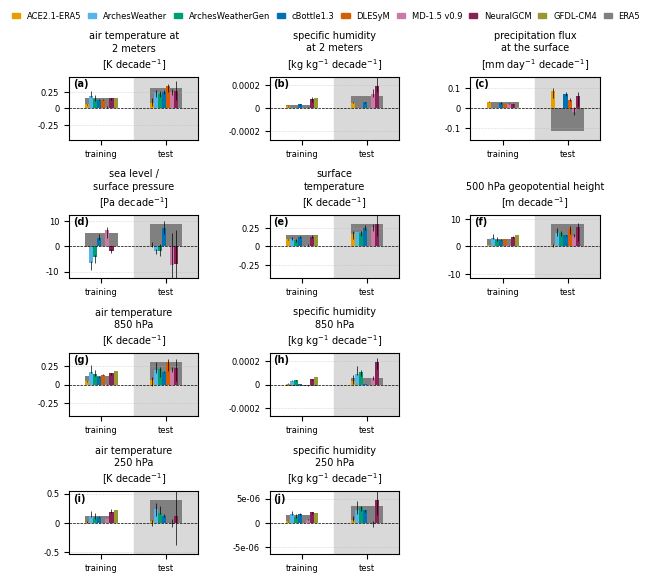

In [35]:
# Appendix Figure: global mean decadal trend bar chart at 2.8° resolution (NeuralGCM included)
# Mirrors the 1° manuscript trend bar; uses regridded_global_annual_means_2p8deg instead.

import matplotlib.ticker as mticker
import textwrap

LABEL_FS = 7

# Compute 2.8° global mean annual means and trends (NeuralGCM included, NeuralGCM-HRD excluded)
global_annual_means_2p8deg = regridded_global_annual_means_2p8deg.sel(year=slice(1979, 2024))
global_annual_mean_era5_2p8deg = regridded_global_annual_mean_era5_2p8deg.sel(year=slice(1979, 2024))

global_mean_trend_2p8deg = xr.concat([
    compute_decadal_trend(global_annual_means_2p8deg, start=TRAINING_DATES[0], end=TRAINING_DATES[1], time_dim_name='year').expand_dims({'time_period': ['training']}),
    compute_decadal_trend(global_annual_means_2p8deg, start=TEST_DATES[0], end=TEST_DATES[1], time_dim_name='year').expand_dims({'time_period': ['test']}),
], dim='time_period')

global_mean_trend_era5_2p8deg = xr.concat([
    compute_decadal_trend(global_annual_mean_era5_2p8deg, start=TRAINING_DATES[0], end=TRAINING_DATES[1], time_dim_name='year').expand_dims({'time_period': ['training']}),
    compute_decadal_trend(global_annual_mean_era5_2p8deg, start=TEST_DATES[0], end=TEST_DATES[1], time_dim_name='year').expand_dims({'time_period': ['test']}),
], dim='time_period')

SURF_VARS_ORDER = ['tas', 'huss', 'pr', 'psl', 'ts', 'zg']
PLEV_VARS_ORDER = ['ta', 'hus']
PLEV_850  = 85000.
PLEV_250  = 25000.
PLEV_ZG   = 50000.
PLEV_ROWS = [(PLEV_850, '850'), (PLEV_250, '250')]

_avail = set(global_mean_trend_2p8deg.data_vars)
surf_vars_plot = [v for v in SURF_VARS_ORDER if v in _avail or v == 'psl']
plev_vars_plot = [v for v in PLEV_VARS_ORDER if v in _avail]

N_COLS = 3
n_surf_rows = 2
n_plev_rows = len(PLEV_ROWS)
n_rows = n_surf_rows + n_plev_rows

fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(n_rows * 1.55, GMD_MAX_HEIGHT_IN)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=N_COLS,
    figsize=(fig_width, fig_height),
    gridspec_kw=dict(hspace=1.2, wspace=0.55),
)
fig.subplots_adjust(top=0.88)

letter_idx = 0
letters = [f'({chr(ord("a") + i)})' for i in range(26)]

def _panel_letter(ax, letter):
    ax.text(0.03, 0.97, letter, transform=ax.transAxes,
            fontsize=LABEL_FS, fontweight='bold', va='top', ha='left')

def _plot_trend_panel(ax, var, trends_var, era5_trends_var, title, pr_scale=1.0):
    trends_scaled = trends_var * pr_scale
    era5_scaled   = era5_trends_var * pr_scale if era5_trends_var is not None else None

    lowest  = trends_scaled.min('realization').to_dataframe().unstack()
    median  = trends_scaled.median('realization').to_dataframe().unstack()
    highest = trends_scaled.max('realization').to_dataframe().unstack()

    median.plot.bar(
        ax=ax, legend=False, color=CATEGORICAL_COLORS,
        yerr=np.concat(
            [(median - lowest).values.T[:, None, :],
             (highest - median).values.T[:, None, :]],
            axis=1,
        ),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if era5_scaled is not None:
        era5_scaled.to_dataframe().unstack().plot.bar(
            ax=ax, color='#808080', zorder=-1, legend=False
        )

    ax.set_axisbelow(True)
    vals = [float(np.nanmax(np.abs(median).values))]
    if era5_scaled is not None:
        vals.append(float(np.nanmax(np.abs(era5_scaled).values)))
    yscale = 1.4 * max(v for v in vals if np.isfinite(v)) if any(np.isfinite(v) and v > 0 for v in vals) else 1.0
    ylim = -yscale, yscale
    xlim = ax.get_xlim()

    xticks = ax.get_xticks()
    shade_x = (xticks[0] + xticks[-1]) / 2 if len(xticks) >= 2 else xlim[1] / 2
    ax.fill_between(
        [shade_x, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]],
        color='#d9d9d9', zorder=-2,
    )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('')
    ax.set_xticklabels([tp for tp in global_mean_trend_2p8deg['time_period'].values],
                       fontsize=LABEL_FS - 1, rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
    ax.set_ylabel('')
    ax.axhline(0, color='k', lw=0.5, ls='--', zorder=1)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='#b3b3b3')
    ax.set_title(title, fontsize=LABEL_FS, linespacing=1.3)

# Merge ps into psl
_gmt2p8 = global_mean_trend_2p8deg
_gmt2p8era5 = global_mean_trend_era5_2p8deg
if 'psl' in _gmt2p8.data_vars and 'ps' in _gmt2p8.data_vars:
    _gmt2p8 = _gmt2p8.assign(psl=_gmt2p8['psl'].fillna(_gmt2p8['ps']))
elif 'ps' in _gmt2p8.data_vars:
    _gmt2p8 = _gmt2p8.assign(psl=_gmt2p8['ps'])
if 'psl' not in _gmt2p8era5.data_vars and 'ps' in _gmt2p8era5.data_vars:
    _gmt2p8era5 = _gmt2p8era5.assign(psl=_gmt2p8era5['ps'])

def _advance_row(ax_flat, ax_idx, N_COLS):
    next_row = ((ax_idx - 1) // N_COLS + 1) * N_COLS
    for i in range(ax_idx, next_row):
        ax_flat[i].set_axis_off()
    return next_row

ax_flat = axes.flatten()
ax_idx  = 0

for var in surf_vars_plot:
    ax = ax_flat[ax_idx]
    _tv = _gmt2p8[var] if var in _gmt2p8.data_vars else None
    if _tv is None:
        ax.set_axis_off()
        ax_idx += 1
        continue

    base_units   = regridded_global_annual_means_2p8deg[var].attrs.get('units', var) if var in regridded_global_annual_means_2p8deg.data_vars else '-'
    raw_longname = _tv.attrs.get('long_name', regridded_global_annual_means_2p8deg[var].attrs.get('long_name', var) if var in regridded_global_annual_means_2p8deg.data_vars else var)
    raw_units    = f'{base_units} decade$^{{-1}}$'
    pr_scale = 1.0
    if var == 'pr':
        raw_units = r'mm day$^{-1}$ decade$^{-1}$'
        pr_scale  = 86400.
    if raw_units in ('1', '1 decade$^{-1}$'):
        raw_units = r'kg kg$^{-1}$ decade$^{-1}$'

    long_name = textwrap.fill(raw_longname.lower(), width=18)
    if var == 'psl':
        long_name = textwrap.fill('sea level / surface pressure', width=18)
    if var == 'zg':
        long_name = textwrap.fill(raw_longname.lower(), width=22)
        title = f'500 hPa {long_name}\n[{raw_units}]'
    else:
        title = f'{long_name}\n[{raw_units}]'

    era5_var = _gmt2p8era5[var] if var in _gmt2p8era5.data_vars else None
    _zg_era5 = era5_var
    _trends = _gmt2p8[var]
    if var == 'zg':
        if 'plev' in _trends.dims:
            _trends = _trends.sel(plev=PLEV_ZG).drop_vars('plev')
        elif 'plev' in _trends.coords:
            _trends = _trends.drop_vars('plev')
        if _zg_era5 is not None:
            if 'plev' in _zg_era5.dims:
                _zg_era5 = _zg_era5.sel(plev=PLEV_ZG).drop_vars('plev')
            elif 'plev' in _zg_era5.coords:
                _zg_era5 = _zg_era5.drop_vars('plev')

    _plot_trend_panel(
        ax, var,
        _trends.transpose('time_period', 'experiment_submission', 'realization'),
        _zg_era5.transpose('time_period') if _zg_era5 is not None else None,
        title, pr_scale=pr_scale,
    )
    _panel_letter(ax, letters[letter_idx])
    letter_idx += 1
    ax_idx += 1

ax_idx = _advance_row(ax_flat, ax_idx, N_COLS)

for plev, plev_label in PLEV_ROWS:
    for var in plev_vars_plot:
        ax = ax_flat[ax_idx]
        _tv = _gmt2p8[var]
        base_units   = regridded_global_annual_means_2p8deg[var].attrs.get('units', var) if var in regridded_global_annual_means_2p8deg.data_vars else '-'
        raw_longname = _tv.attrs.get('long_name', var)
        raw_units    = f'{base_units} decade$^{{-1}}$'
        if raw_units in ('1', '1 decade$^{-1}$'):
            raw_units = r'kg kg$^{-1}$ decade$^{-1}$'
        long_name = textwrap.fill(raw_longname.lower(), width=18)
        title = f'{long_name}\n{plev_label} hPa\n[{raw_units}]'

        trends_plev = (
            _gmt2p8[var].sel(plev=plev).drop_vars('plev')
            .transpose('time_period', 'experiment_submission', 'realization')
        )
        era5_plev = (
            _gmt2p8era5[var].sel(plev=plev).drop_vars('plev').transpose('time_period')
            if var in _gmt2p8era5.data_vars else None
        )
        _plot_trend_panel(ax, var, trends_plev, era5_plev, title)
        _panel_letter(ax, letters[letter_idx])
        letter_idx += 1
        ax_idx += 1
    ax_idx = _advance_row(ax_flat, ax_idx, N_COLS)

exp_names_2p8deg = list(regridded_global_annual_means_2p8deg.coords['experiment_submission'].values)
bar_handles = [
    plt.Rectangle((0, 0), 1, 1, color=CATEGORICAL_COLORS[i])
    for i in range(len(exp_names_2p8deg))
]
era5_handle = plt.Rectangle((0, 0), 1, 1, color='#808080')
fig.legend(
    bar_handles + [era5_handle],
    exp_names_2p8deg + ['ERA5'],
    fontsize=LABEL_FS - 1,
    loc='upper center',
    ncol=len(exp_names_2p8deg) + 1,
    bbox_to_anchor=(0.5, 0.995),
    frameon=False,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.0,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'app_trend_bar_2p8deg_surface_and_plev')
plt.show()